In [17]:
import os
from pathlib import Path
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance, ImageDraw

In [18]:
def apply_blur(img, radius):
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def apply_brightness(img, factor):
    return ImageEnhance.Brightness(img).enhance(factor)

def apply_contrast(img, factor):
    return ImageEnhance.Contrast(img).enhance(factor)

def apply_noise(img, sigma):
    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(loc=0.0, scale=sigma, size=arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def apply_jpeg_compression(img, quality):
    # Save/reload in memory to simulate JPEG artifacts
    from io import BytesIO
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def apply_rotation(img, angle):
    # Keep same size so annotations can still be reused approximately
    return img.rotate(angle, resample=Image.BILINEAR, expand=False, fillcolor=(255, 255, 255))

def apply_shadow(img, alpha=0.30):
    """
    Adds a shadow-like dark region across part of the page.
    alpha: darkness strength in [0,1]
    """
    img = img.convert("RGB")
    W, H = img.size

    # Original image as numpy
    arr = np.array(img).astype(np.float32)

    # Create mask
    mask = Image.new("L", (W, H), 0)
    draw = ImageDraw.Draw(mask)

    # Slightly diagonal polygon shadow
    polygon = [
        (0, int(0.25 * H)),
        (int(0.55 * W), 0),
        (W, int(0.35 * H)),
        (int(0.45 * W), H),
        (0, H),
    ]
    draw.polygon(polygon, fill=255)

    # Blur the mask for smoother shadow edge
    mask = mask.filter(ImageFilter.GaussianBlur(radius=max(8, W // 100)))
    mask_arr = np.array(mask).astype(np.float32) / 255.0

    # Darken only masked region
    factor = 1.0 - alpha * mask_arr[..., None]
    shadowed = np.clip(arr * factor, 0, 255).astype(np.uint8)

    return Image.fromarray(shadowed)

In [19]:
CORRUPTION_CONFIG = {
    "blur": {
        "mild":   {"radius": 2},
        "medium": {"radius": 5},
        "strong": {"radius": 9},
    },
    "noise": {
        "mild":   {"sigma": 5},
        "medium": {"sigma": 12},
        "strong": {"sigma": 20},
    },
    "jpeg": {
        "mild":   {"quality": 50},
        "medium": {"quality": 25},
        "strong": {"quality": 10},
    },
    "brightness": {
        "mild":   {"factor": 0.85},
        "medium": {"factor": 0.65},
        "strong": {"factor": 0.45},
    },
    "contrast": {
        "mild":   {"factor": 0.85},
        "medium": {"factor": 0.65},
        "strong": {"factor": 0.45},
    },
    "rotation": {
        "mild":   {"angle": 5},
        "medium": {"angle": 10},
        "strong": {"angle": 15},
    },
    "shadow": {
        "mild":   {"alpha": 0.15},
        "medium": {"alpha": 0.30},
        "strong": {"alpha": 0.45},
    },
}

In [23]:
SOURCE_TEST_DIR = "sampled_test"   # your clean unseen scanned test images
OUTPUT_ROOT = "corrupted_test_sets"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

In [21]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

source_paths = sorted(
    [p for p in Path(SOURCE_TEST_DIR).iterdir() if p.suffix.lower() in VALID_EXTS]
)

print(f"Found {len(source_paths)} source test images.")

for corruption_name, severities in CORRUPTION_CONFIG.items():
    for severity_name, params in severities.items():
        out_dir = Path(OUTPUT_ROOT) / f"test_{corruption_name}_{severity_name}"
        out_dir.mkdir(parents=True, exist_ok=True)

        print(f"\nCreating: {out_dir}")

        for img_path in source_paths:
            img = Image.open(img_path).convert("RGB")

            if corruption_name == "blur":
                out_img = apply_blur(img, **params)
            elif corruption_name == "noise":
                out_img = apply_noise(img, **params)
            elif corruption_name == "jpeg":
                out_img = apply_jpeg_compression(img, **params)
            elif corruption_name == "brightness":
                out_img = apply_brightness(img, **params)
            elif corruption_name == "contrast":
                out_img = apply_contrast(img, **params)
            elif corruption_name == "rotation":
                out_img = apply_rotation(img, **params)
            elif corruption_name == "shadow":
                out_img = apply_shadow(img, **params)
            else:
                raise ValueError(f"Unknown corruption: {corruption_name}")

            out_path = out_dir / img_path.name
            out_img.save(out_path)

print("\nDone creating corrupted test sets.")

Found 50 source test images.

Creating: sampled_test_corruptions/test_blur_mild

Creating: sampled_test_corruptions/test_blur_medium

Creating: sampled_test_corruptions/test_blur_strong

Creating: sampled_test_corruptions/test_noise_mild

Creating: sampled_test_corruptions/test_noise_medium

Creating: sampled_test_corruptions/test_noise_strong

Creating: sampled_test_corruptions/test_jpeg_mild

Creating: sampled_test_corruptions/test_jpeg_medium

Creating: sampled_test_corruptions/test_jpeg_strong

Creating: sampled_test_corruptions/test_brightness_mild

Creating: sampled_test_corruptions/test_brightness_medium

Creating: sampled_test_corruptions/test_brightness_strong

Creating: sampled_test_corruptions/test_contrast_mild

Creating: sampled_test_corruptions/test_contrast_medium

Creating: sampled_test_corruptions/test_contrast_strong

Creating: sampled_test_corruptions/test_rotation_mild

Creating: sampled_test_corruptions/test_rotation_medium

Creating: sampled_test_corruptions/test_

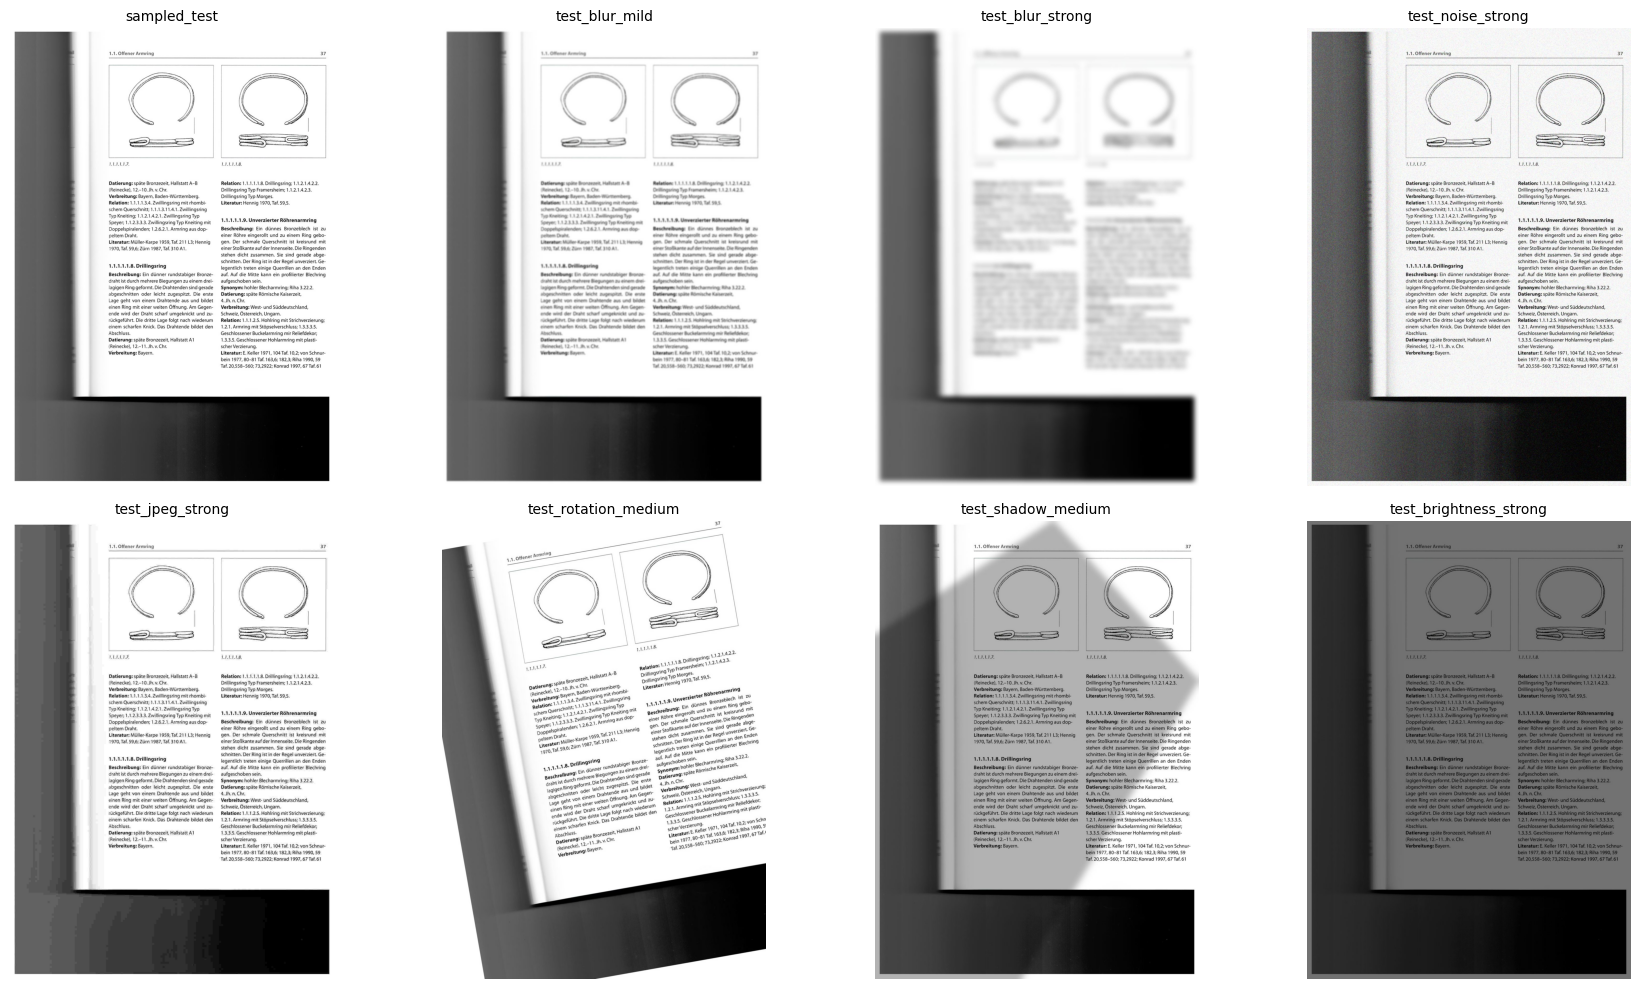

In [22]:
import matplotlib.pyplot as plt

sample_name = source_paths[0].name

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

paths_to_show = [
    Path(SOURCE_TEST_DIR) / sample_name,
    Path(OUTPUT_ROOT) / "test_blur_mild" / sample_name,
    Path(OUTPUT_ROOT) / "test_blur_strong" / sample_name,
    Path(OUTPUT_ROOT) / "test_noise_strong" / sample_name,
    Path(OUTPUT_ROOT) / "test_jpeg_strong" / sample_name,
    Path(OUTPUT_ROOT) / "test_rotation_medium" / sample_name,
    Path(OUTPUT_ROOT) / "test_shadow_medium" / sample_name,
    Path(OUTPUT_ROOT) / "test_brightness_strong" / sample_name,
]

for ax, p in zip(axes, paths_to_show):
    img = Image.open(p).convert("RGB")
    ax.imshow(img)
    ax.set_title(p.parent.name, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()